# exp-h2-evidence-shape-01 — 공유형 evidence-shape pairwise ranker

## 가설
규정 안전 H0는 gene×event-type Empirical-Bayes 증거를 암종별 합계로 압축한다. H2-S는 각 환자×암종 후보에서 양·음 evidence, 집중도, support, H0 확률/순위 등 **19개 evidence-shape**를 보존하고, 모든 암종쌍에 하나의 계수를 공유하는 pairwise LR로 26개 후보 순위를 잔차 보정한다.

## 고정 조건
- H0: self-contained 안전 LR 0.80 + train-discovered LGBM hard specialist 0.20
- Outer: Stratified 5-fold, seed 42 / Inner: Stratified 3-fold
- Pairwise LR: `C=0.035`, `max_iter=2000`; correction strength는 inner OOF에서 `{0.10, 0.20}` 중 하나만 선택
- seed42 screen에서는 `train.csv`만 읽고 `test.csv`를 읽지 않는다.

## Dacon·팀 안전 계약
고정 암종명·유전자명·exact mutation 목록을 사용하지 않는다. event vocabulary, recurrent event, EB 통계, 자동 specialist 쌍은 각 outer-fold train에서만 자동 학습한다. inner OOF로만 pairwise meta-feature/ranker를 학습하고 outer validation은 transform·평가만 한다. WT·빈 문자열·NaN은 event를 만들지 않는다.

In [1]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
EXP_DIR = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_006'
RUNNER = EXP_DIR / 'common' / 'run_h2_evidence_shape_pairwise.py'
RESULT = EXP_DIR / 'result'
RUN_ID = 'exp-h2-evidence-shape-01'
RUN_EXPERIMENT = True  # 검증 후 True로 바꾼 뒤, 이 셀만 실행
assert RUNNER.exists() and (ROOT / 'data/raw/train.csv').exists()
print({'runner': RUNNER, 'result_dir': RESULT, 'run_experiment': RUN_EXPERIMENT})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/common/run_h2_evidence_shape_pairwise.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/result'), 'run_experiment': True}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 전체 CV 전에 항상 실행: 문법·경로·train schema·NaN parser·결과 schema smoke test
subprocess.run([sys.executable, str(RUNNER), '--smoke'], check=True)

{"smoke": "ok", "rows": 8, "genes": 4384, "test_read": false, "nan_as_mutation_count": 0, "required_result_schemas": {"summary": ["convergence_warning_count", "delta_vs_h0", "feature_count", "leakage_check", "nan_as_mutation_count", "oof_accuracy", "oof_macro_f1", "runtime_seconds", "variant"], "fold_metrics": ["accuracy", "alpha", "feature_count", "fold", "macro_f1", "variant"], "class_metrics": ["class", "delta_f1", "h0_f1", "h2_f1", "support"]}}


CompletedProcess(args=['/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/bin/python', '/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/common/run_h2_evidence_shape_pairwise.py', '--smoke'], returncode=0)

In [3]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='H2-S outer folds', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('H2-S runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 전체 CV는 실행하지 않았습니다.')

H2-S outer folds: 1line [00:05,  5.00s/line]

[H2-S] outer fold 1/5: inner OOF meta features


H2-S outer folds: 2line [09:20, 329.08s/line]

[H2-S] outer fold 1/5: outer train fit / validation transform (alpha=0.20)


H2-S outer folds: 3line [13:15, 285.82s/line]

...

H2-S outer folds: 10line [1:04:32, 441.38s/line]

[H2-S] outer fold 5/5: outer train fit / validation transform (alpha=0.20)


H2-S outer folds: 11line [1:08:39, 382.14s/line]

{"h0": 0.5237165047556878, "h2": 0.5255605612732557, "delta": 0.0018440565175679158, "h0_reference_macro_f1": 0.543679, "h0_reference_delta": -0.01996249524431226, "h0_reference_match": false, "low_margin_delta": 0.028991835072676386, "delta_at_least_0015": false, "four_positive_folds": true, "low_margin_not_below_minus_0003": true, "no_single_fold_dominates": true, "no_single_class_dominates": true, "decision": "baseline_not_reproduced", "new_top3_recovered_rows": 28, "h0_correct_h2_broken_rows": 35, "pairwise_coefficient_norm_mean": 2.1469196557998655, "pairwise_coefficient_norm_max": 2.48264217376709}


H2-S outer folds: 11line [1:08:40, 374.59s/line]


In [4]:
import json
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed42_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed42_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_seed42_class_metrics.csv')
topk = pd.read_csv(RESULT / f'{RUN_ID}_seed42_topk.csv')
low = pd.read_csv(RESULT / f'{RUN_ID}_seed42_low_margin.csv')
audit = json.loads((RESULT / f'{RUN_ID}_seed42_leakage_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
assert audit['test_read'] is False and audit['leakage_check'] is True
display(summary)
display(folds.pivot(index='fold', columns='variant', values='macro_f1'))
display(pd.DataFrame([audit['selection']]))

,variant,oof_macro_f1,oof_accuracy,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0,delta_vs_h0_reference
0,H0,0.523717,0.545235,8325.4,0,True,0,4117.576474,0.000000,-0.019962
1,H2_S,0.525561,0.548460,19.0,0,True,0,4117.600794,0.001844,-0.018118


variant,H0,H2_S
fold,,
1,0.497154,0.499173
2,0.539092,0.542039
3,0.508231,0.507721
4,0.537984,0.540932
5,0.534212,0.535868


,h0,h2,delta,h0_reference_macro_f1,h0_reference_delta,h0_reference_match,low_margin_delta,delta_at_least_0015,four_positive_folds,low_margin_not_below_minus_0003,no_single_fold_dominates,no_single_class_dominates,decision,new_top3_recovered_rows,h0_correct_h2_broken_rows,pairwise_coefficient_norm_mean,pairwise_coefficient_norm_max
0,0.523717,0.525561,0.001844,0.543679,-0.019962,False,0.028992,False,True,True,True,True,baseline_not_reproduced,28,35,2.14692,2.482642


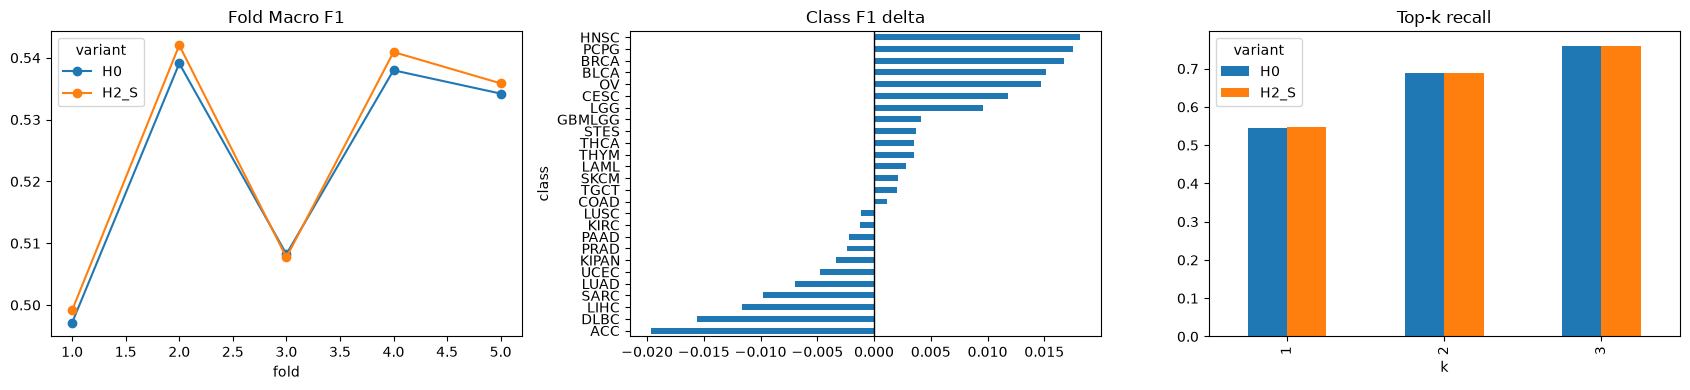

,variant,group,support,macro_f1
0,H0,h0_margin_lt_005,1080,0.220665
1,H2_S,h0_margin_lt_005,1080,0.249657


자동 판정: baseline_not_reproduced


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
folds.pivot(index='fold', columns='variant', values='macro_f1').plot(marker='o', ax=axes[0], title='Fold Macro F1')
classes.sort_values('delta_f1').plot.barh(x='class', y='delta_f1', ax=axes[1], legend=False, title='Class F1 delta')
axes[1].axvline(0, color='black', linewidth=1)
topk.pivot(index='k', columns='variant', values='recall').plot.bar(ax=axes[2], title='Top-k recall')
plt.tight_layout(); plt.show()
display(low)
print('자동 판정:', audit['selection']['decision'])